#  Unveiling the Android App Market

## Project Overview

The objective of this project is to analyze Google Play Store data to understand app market dynamics through data cleaning, visualization, and exploratory data analysis.

The project focuses on app categories, ratings, installs, pricing, user sentiments, and other important metrics that influence app popularity and success.

## Import Libraries

Import the required libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

Load the Google Play Store dataset and User Reviews dataset.

In [7]:
apps = pd.read_csv("/content/apps.csv")

reviews = pd.read_csv("/content/user_reviews.csv")

apps.head()


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Data Preparation

Data cleaning improves the quality of analysis by handling missing values, duplicates, and incorrect data types.

In [8]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [9]:
apps.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [10]:
apps.drop_duplicates(inplace=True)

In [11]:
apps.dropna(inplace=True)

## Category Exploration

This analysis examines the distribution of applications across different Google Play Store categories.

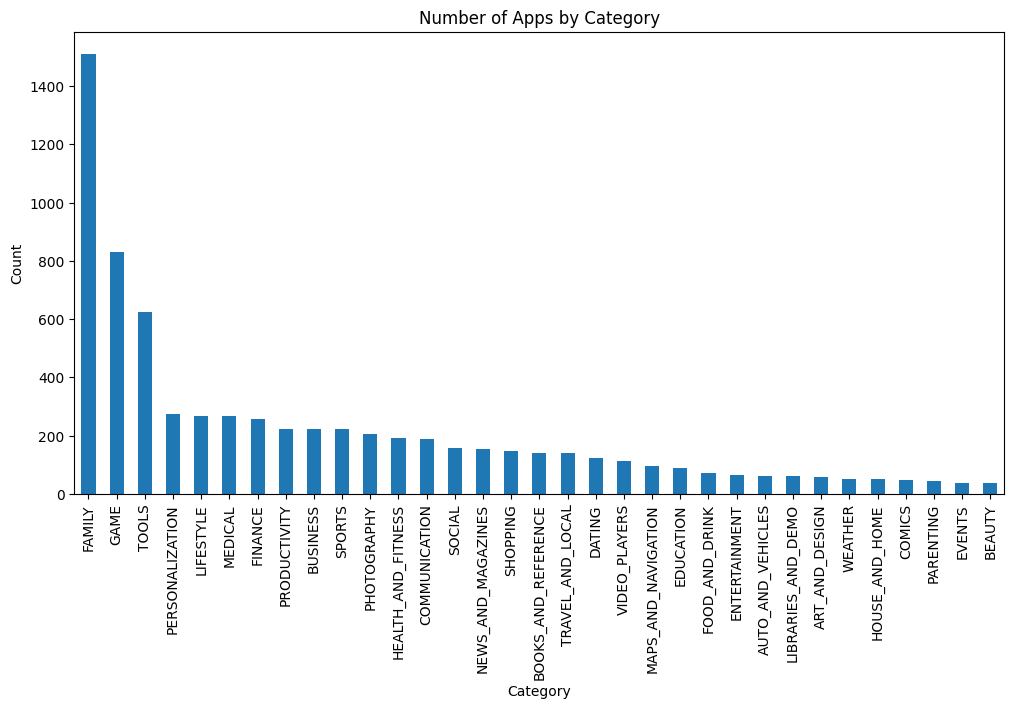

In [13]:
plt.figure(figsize=(12,6))

apps["Category"].value_counts().plot(kind="bar")

plt.title("Number of Apps by Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

##Interpretation

Family, Game, and Tools categories contain the largest number of applications, indicating high developer activity and strong market competition in these domains.

## App Rating Analysis

Ratings provide valuable insights into user satisfaction and application quality.

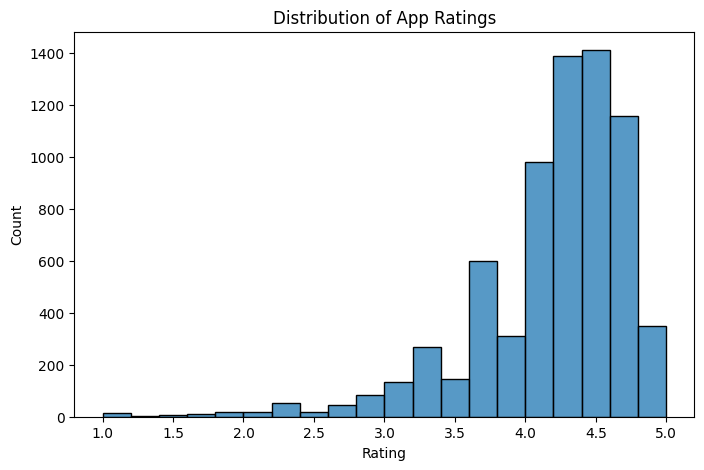

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(apps["Rating"],bins=20)

plt.title("Distribution of App Ratings")

plt.show()

##Interpretation

Most applications receive ratings between 4.0 and 4.5, suggesting that users generally provide positive feedback.

## App Popularity Analysis

The number of installs reflects the popularity and market reach of applications.

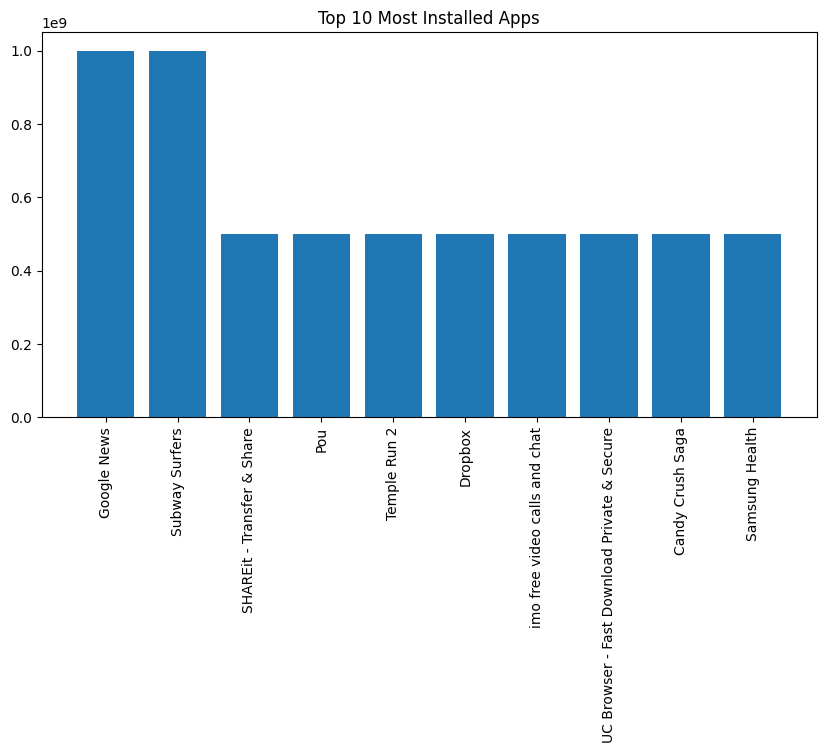

In [19]:
apps["Installs"] = apps["Installs"].astype(str).str.replace(",","")

apps["Installs"] = apps["Installs"].str.replace("+","",regex=False)

apps["Installs"] = apps["Installs"].astype(int)

top = apps.sort_values("Installs",ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top["App"],top["Installs"])

plt.xticks(rotation=90)

plt.title("Top 10 Most Installed Apps")

plt.show()

##Interpretation

Applications from major companies dominate the market with billions of installs, reflecting strong brand recognition and user trust.

## Pricing Analysis

This section compares the distribution of free and paid applications available on the Google Play Store.

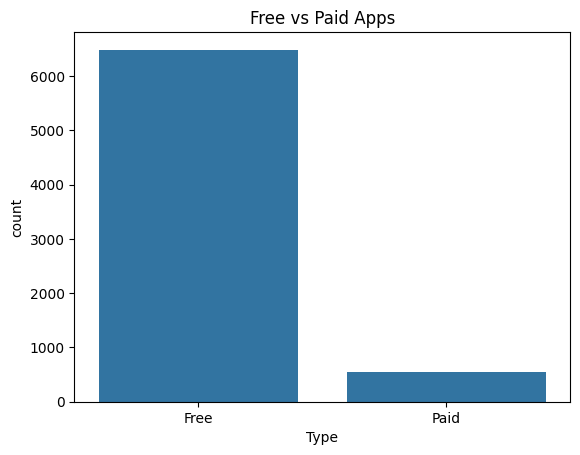

In [20]:
sns.countplot(x="Type",data=apps)

plt.title("Free vs Paid Apps")

plt.show()

##Interpretation

Free applications significantly outnumber paid applications, indicating that developers commonly adopt ad-supported and in-app purchase business models.

## App Size Analysis

Analyzing app size helps understand storage requirements and user preferences.

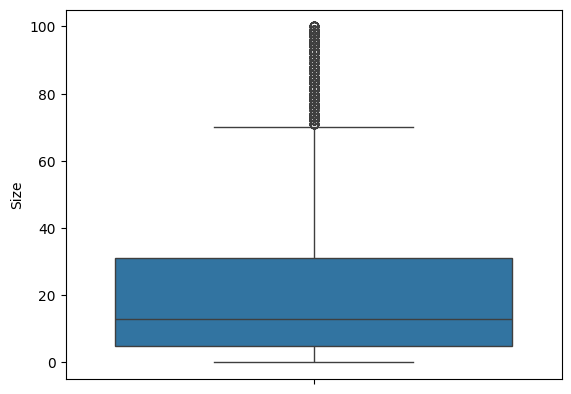

In [23]:
apps["Size"] = apps["Size"].astype(str) # Convert to string type first
apps["Size"] = apps["Size"].str.replace("M","")

apps["Size"] = apps["Size"].replace("Varies with device",np.nan)

apps["Size"] = pd.to_numeric(apps["Size"])

sns.boxplot(y=apps["Size"])

plt.show()

##Interpretation

Most applications have moderate sizes, while a few large applications appear as outliers due to their extensive features and content.

## Sentiment Analysis

User reviews provide valuable insights into customer satisfaction and application quality.

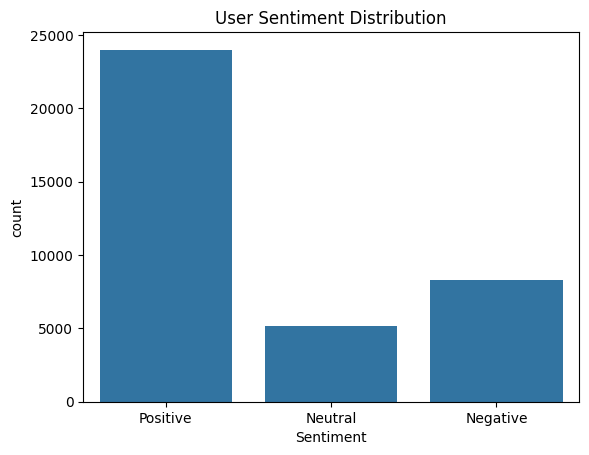

In [22]:
sns.countplot(x="Sentiment",data=reviews)

plt.title("User Sentiment Distribution")

plt.show()

##Interpretation

Positive reviews dominate the dataset, indicating that users are generally satisfied with the majority of applications available on the Google Play Store.

## Interactive Visualization

Correlation analysis helps identify relationships among numerical variables.

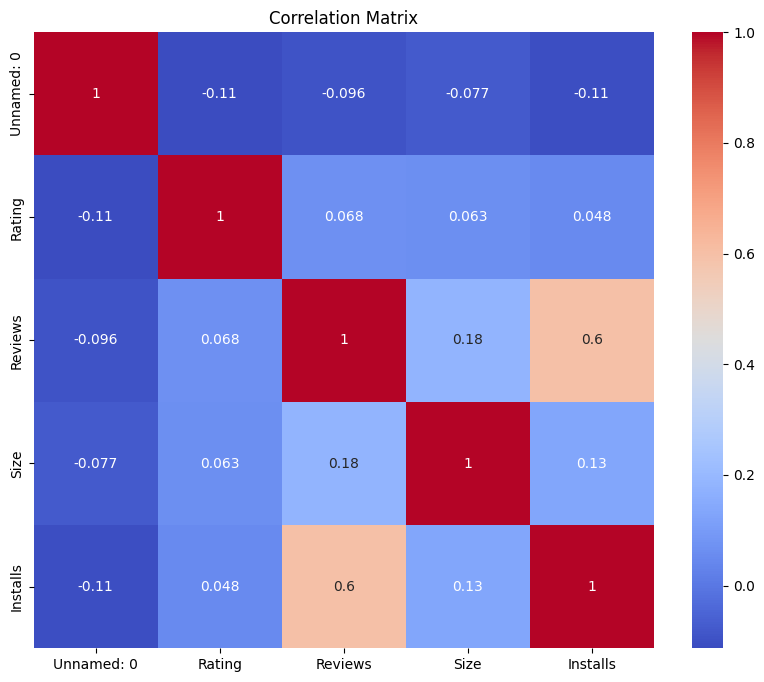

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(apps.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

##Interpretation

The heatmap reveals relationships among numerical features such as ratings, reviews, installs, and size, helping identify factors that influence app popularity.